[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/scw634919-bfty/ecommerce-data-analytics-portfolio/blob/main/3-inventory-optimization-analysis/notebook/inventory_optimization_analysis.ipynb)

# E-commerce Inventory Optimization & Reorder Decision Analysis

This project analyzes e-commerce transaction data to identify sales performance, inventory health, slow-moving SKUs, and reorder recommendations.

**Business Goal:** Move beyond basic reporting and create a simple decision-support workflow for inventory planning.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Load Data

The dataset is loaded from an Excel file. If you use a CSV file instead, replace `pd.read_excel()` with `pd.read_csv()`.

In [3]:
# Load the transaction dataset
df = pd.read_excel("Online Retail.xlsx")

# Preview the dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


## 3. Data Cleaning

Real-world sales data often includes cancellations, returns, missing product names, or invalid prices. This section cleans the dataset before analysis.

In [4]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower()

# Rename columns for easier business interpretation
df = df.rename(columns={
    "stockcode": "sku",
    "description": "product_name",
    "invoicedate": "invoice_date",
    "unitprice": "unit_price"
})

# Convert invoice date to datetime if available
if "invoice_date" in df.columns:
    df["invoice_date"] = pd.to_datetime(df["invoice_date"], errors="coerce")

# Keep valid sales only: positive quantity and positive price
df = df[(df["quantity"] > 0) & (df["unit_price"] > 0)].copy()

# Remove rows with missing SKU or product name
df = df.dropna(subset=["sku", "product_name"])

# Create revenue column
df["revenue"] = df["quantity"] * df["unit_price"]

# Check cleaned data
df.head()

,invoiceno,sku,product_name,quantity,invoice_date,unit_price,customerid,country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34


## 4. Product Category Creation

Because the dataset does not include clean product categories, this project creates simple rule-based categories from product names. In a real company, this could be replaced with a product master table.

In [5]:
def categorize(desc):

    desc = str(desc).lower()

    # Home decor (largest category in this dataset)
    if any(word in desc for word in [
        "candle", "holder", "lamp", "frame",
        "mirror", "vase", "clock", "heart",
        "flower", "light", "decor", "ornament",
        "door", "picture", "sign", "hanger",
        "shelf", "storage", "box", "drawer"
    ]):
        return "home decor"

    # Kitchen / dining
    elif any(word in desc for word in [
        "kitchen", "tea", "coffee", "mug",
        "cup", "plate", "bowl", "glass",
        "bottle", "jar", "tin", "cutlery",
        "spoon", "fork", "knife", "tray",
        "baking", "pan", "kettle", "teapot",
        "cake"
    ]):
        return "kitchen"

    # Bags
    elif any(word in desc for word in [
        "bag", "purse", "tote",
        "lunch bag", "shopping bag",
        "backpack"
    ]):
        return "bags"

    # Gift / decorative
    elif any(word in desc for word in [
        "gift", "present", "ribbon",
        "card", "wrap", "wrapping",
        "party", "bunting", "decorative"
    ]):
        return "gift/decorative"

    # Seasonal
    elif any(word in desc for word in [
        "christmas", "xmas", "santa",
        "snow", "tree", "easter",
        "halloween", "valentine",
        "seasonal"
    ]):
        return "seasonal"

    # Sets / bundles
    elif any(word in desc for word in [
        "set", "kit", "pack", "bundle"
    ]):
        return "sets"

    # Stationery
    elif any(word in desc for word in [
        "paper", "notebook", "note",
        "stationery", "pen", "pencil",
        "file", "folder", "sticker"
    ]):
        return "stationery"

    else:
        return "other"


# Apply category mapping
df["category"] = df["product_name"].apply(categorize)

df[["sku", "product_name", "category"]].head()

,sku,product_name,category
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,home decor
1,71053,WHITE METAL LANTERN,other
2,84406B,CREAM CUPID HEARTS COAT HANGER,home decor
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,kitchen
4,84029E,RED WOOLLY HOTTIE WHITE HEART.,home decor


## 5. Sales Trend Analysis

This section reviews overall monthly sales performance to understand demand patterns over time.

,invoice_date,units_sold,revenue
0,2010-12-31,359239,"823,746.14"
1,2011-01-31,387785,"691,364.56"
2,2011-02-28,283555,"523,631.89"
3,2011-03-31,377526,"717,639.36"
4,2011-04-30,308815,"537,808.62"


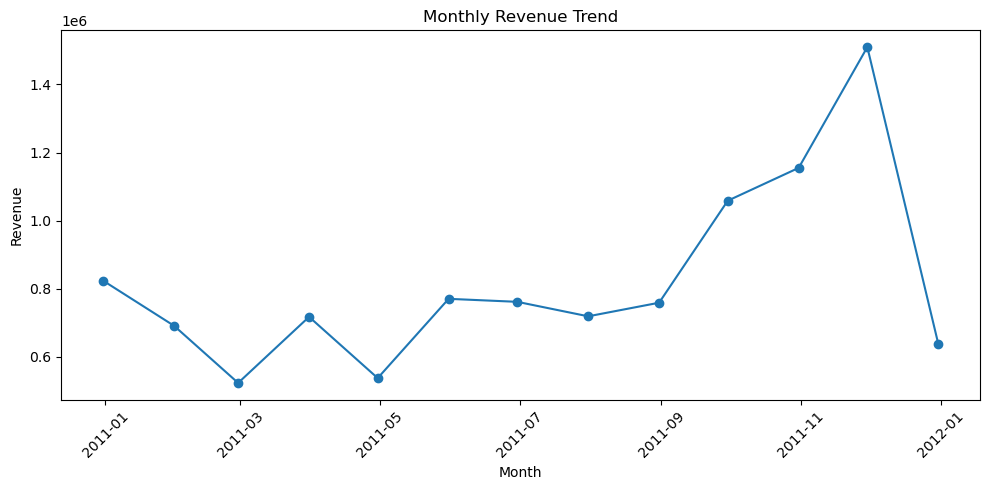

In [6]:
# Monthly sales trend
if "invoice_date" in df.columns:
    monthly_sales = (
        df.set_index("invoice_date")
          .resample("ME")
          .agg(units_sold=("quantity", "sum"), revenue=("revenue", "sum"))
          .reset_index()
    )

    display(monthly_sales.head())

    plt.figure(figsize=(10, 5))
    plt.plot(monthly_sales["invoice_date"], monthly_sales["revenue"], marker="o")
    plt.title("Monthly Revenue Trend")
    plt.xlabel("Month")
    plt.ylabel("Revenue")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("invoice_date column is not available, so monthly trend analysis is skipped.")

## 6. Best Seller & Category Performance

This section identifies top-selling SKUs and category-level performance.

,sku,product_name,category,units_sold,revenue,avg_unit_price
2390,23843,"PAPER CRAFT , LITTLE BIRDIE",stationery,80995,"168,469.60",2.08
1945,23166,MEDIUM CERAMIC TOP STORAGE JAR,home decor,78033,"81,700.92",1.47
1034,22197,SMALL POPCORN HOLDER,home decor,56921,"51,354.02",1.04
2562,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,home decor,55047,"13,841.85",0.32
3528,85099B,JUMBO BAG RED RETROSPOT,bags,48474,"94,340.05",2.49
3539,85123A,WHITE HANGING HEART T-LIGHT HOLDER,home decor,37660,"104,518.80",3.12
2666,84879,ASSORTED COLOUR BIRD ORNAMENT,home decor,36461,"59,094.93",1.72
364,21212,PACK OF 72 RETROSPOT CAKE CASES,kitchen,36419,"21,259.10",0.76
1867,23084,RABBIT NIGHT LIGHT,home decor,30788,"66,964.99",2.38
1299,22492,MINI PAINT SET VINTAGE,sets,26633,"16,937.82",0.79


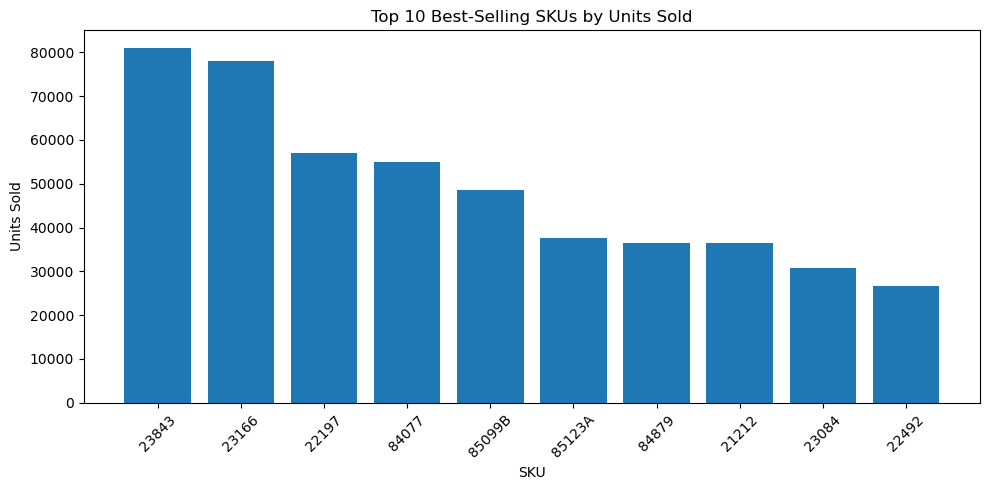

In [7]:
# SKU-level sales performance
sku_sales = (
    df.groupby("sku", as_index=False)
      .agg(
          product_name=("product_name", "first"),
          category=("category", "first"),
          units_sold=("quantity", "sum"),
          revenue=("revenue", "sum"),
          avg_unit_price=("unit_price", "mean")
      )
)

# Best sellers by units sold
top_skus = sku_sales.sort_values("units_sold", ascending=False).head(10)
display(top_skus)

plt.figure(figsize=(10, 5))
plt.bar(top_skus["sku"].astype(str), top_skus["units_sold"])
plt.title("Top 10 Best-Selling SKUs by Units Sold")
plt.xlabel("SKU")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

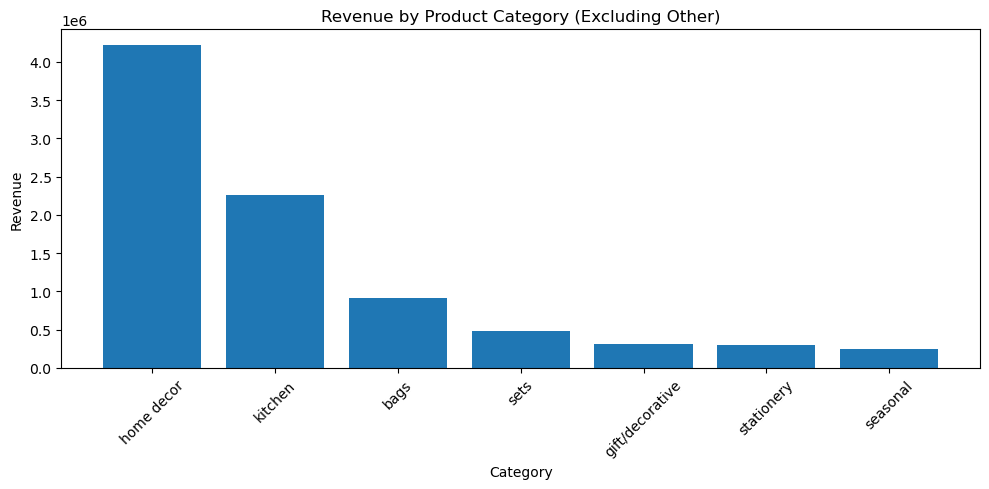

In [8]:
# Category-level performance
# Category summary excluding "other" for clearer business interpretation

category_summary = (
    df[df["category"] != "other"]
    .groupby("category")
    .agg(
        total_units_sold=("quantity", "sum"),
        total_revenue=("revenue", "sum"),
        sku_count=("sku", "nunique")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

category_summary

plt.figure(figsize=(10, 5))

plt.bar(
    category_summary["category"],
    category_summary["total_revenue"]
)

plt.title("Revenue by Product Category (Excluding Other)")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Inventory Health Analysis

The original dataset does not include real beginning or ending inventory. To demonstrate inventory decision logic, this project simulates inventory based on sales volume.

In a real business setting, this section should use actual on-hand inventory from a WMS, ERP, or Shopify inventory export.

In [9]:
# Simulate inventory for portfolio demonstration
np.random.seed(42)

inventory = sku_sales.copy()
inventory["begin_inventory"] = inventory["units_sold"] + np.random.randint(10, 100, size=len(inventory))
inventory["ending_inventory"] = inventory["begin_inventory"] - inventory["units_sold"]

# Inventory KPIs
inventory["sell_through_rate"] = inventory["units_sold"] / inventory["begin_inventory"]
inventory["avg_inventory"] = (inventory["begin_inventory"] + inventory["ending_inventory"]) / 2
inventory["inventory_turnover"] = inventory["units_sold"] / inventory["avg_inventory"]

# Inventory status flags
inventory["overstock_flag"] = inventory["ending_inventory"] > inventory["units_sold"]
inventory["stockout_risk_flag"] = inventory["ending_inventory"] < inventory["units_sold"] * 0.20

inventory.head()

,sku,product_name,category,units_sold,revenue,avg_unit_price,begin_inventory,ending_inventory,sell_through_rate,avg_inventory,inventory_turnover,overstock_flag,stockout_risk_flag
0,10002,INFLATABLE POLITICAL GLOBE,other,860,759.89,1.09,921,61,0.93,491.00,1.75,False,True
1,10080,GROOVY CACTUS INFLATABLE,other,303,119.09,0.41,327,24,0.93,175.50,1.73,False,True
2,10120,DOGGY RUBBER,other,193,40.53,0.21,274,81,0.70,177.50,1.09,False,False
3,10125,MINI FUNKY DESIGN TAPES,home decor,1296,994.84,0.86,1366,70,0.95,718.00,1.81,False,True
4,10133,COLOURING PENCILS BROWN TUBE,stationery,2867,"1,544.22",0.65,2897,30,0.99,"1,463.50",1.96,False,True


In [10]:
# Inventory KPI summary
inventory_summary = pd.DataFrame({
    "metric": [
        "Total SKUs",
        "Average Sell-Through Rate",
        "Average Inventory Turnover",
        "Overstock SKUs",
        "Stockout Risk SKUs"
    ],
    "value": [
        inventory["sku"].nunique(),
        inventory["sell_through_rate"].mean(),
        inventory["inventory_turnover"].mean(),
        inventory["overstock_flag"].sum(),
        inventory["stockout_risk_flag"].sum()
    ]
})

display(inventory_summary)

,metric,value
0,Total SKUs,"3,922.00"
1,Average Sell-Through Rate,0.73
2,Average Inventory Turnover,1.30
3,Overstock SKUs,926.00
4,Stockout Risk SKUs,"2,255.00"


## 8. Slow-Moving SKU Detection

Slow-moving SKUs are items with low sell-through and remaining inventory. These products may create overstock risk or tie up cash in inventory.

In [11]:
# Define slow-moving SKUs
slow_moving_skus = (
    inventory[
        (inventory["sell_through_rate"] < 0.30) &
        (inventory["ending_inventory"] > 0)
    ]
    .sort_values(["sell_through_rate", "ending_inventory"], ascending=[True, False])
)

display(slow_moving_skus[[
    "sku", "product_name", "category", "units_sold", "ending_inventory",
    "sell_through_rate", "inventory_turnover"
]].head(15))

,sku,product_name,category,units_sold,ending_inventory,sell_through_rate,inventory_turnover
2796,90068,"RUBY GLASS NECKLACE 42""",kitchen,1,98,0.01,0.01
3494,85035b,CHOCOLATE 3 WICK MORRIS BOX CANDLE,home decor,1,97,0.01,0.01
2524,77079,DOLPHIN WINDMILL,other,1,96,0.01,0.01
3907,DCGS0070,CAMOUFLAGE DOG COLLAR,other,1,95,0.01,0.01
87,20703,BLUE PADDED SOFT MOBILE,other,1,94,0.01,0.01
3145,72803b,OCEAN SCENT CANDLE JEWELLED DRAWER,home decor,1,94,0.01,0.01
2772,90020,FILIGREE DIAMANTE CHAIN,other,1,93,0.01,0.01
3211,84031a,CHARLIE+LOLA RED HOT WATER BOTTLE,kitchen,1,92,0.01,0.01
2469,47579,TEA TIME BREAKFAST BASKET,kitchen,1,91,0.01,0.01
3321,84661a,WHITE SQUARE TABLE CLOCK,home decor,1,90,0.01,0.01


## 9. Reorder Recommendation Logic

This section turns the analysis into a business recommendation. The logic estimates reorder needs using average demand, lead time, and safety stock.

**Formula used:**

`Reorder Point = Expected Demand During Lead Time + Safety Stock`

For this portfolio project, weekly demand is estimated from historical sales.

In [12]:
# Estimate demand assumptions
if "invoice_date" in df.columns:
    date_range_days = (df["invoice_date"].max() - df["invoice_date"].min()).days
    weeks_in_data = max(date_range_days / 7, 1)
else:
    weeks_in_data = 52

lead_time_weeks = 4
safety_stock_weeks = 2

inventory["estimated_weekly_demand"] = inventory["units_sold"] / weeks_in_data
inventory["expected_demand_lead_time"] = inventory["estimated_weekly_demand"] * lead_time_weeks
inventory["safety_stock"] = inventory["estimated_weekly_demand"] * safety_stock_weeks
inventory["reorder_point"] = inventory["expected_demand_lead_time"] + inventory["safety_stock"]

inventory["recommended_reorder_qty"] = (
    inventory["reorder_point"] - inventory["ending_inventory"]
).clip(lower=0).round(0)

# Create business recommendation label
def make_recommendation(row):
    if row["recommended_reorder_qty"] > 0 and row["stockout_risk_flag"]:
        return "Reorder immediately"
    elif row["recommended_reorder_qty"] > 0:
        return "Monitor and reorder soon"
    elif row["overstock_flag"] or row["sell_through_rate"] < 0.30:
        return "Consider promotion or bundle"
    else:
        return "Healthy inventory"

inventory["recommendation"] = inventory.apply(make_recommendation, axis=1)

# Review recommendation output
recommendation_table = inventory[[
    "sku", "product_name", "category", "units_sold", "ending_inventory",
    "sell_through_rate", "estimated_weekly_demand", "reorder_point",
    "recommended_reorder_qty", "recommendation"
]].sort_values(["recommended_reorder_qty", "units_sold"], ascending=[False, False])

display(recommendation_table.head(20))

,sku,product_name,category,units_sold,ending_inventory,sell_through_rate,estimated_weekly_demand,reorder_point,recommended_reorder_qty,recommendation
2390,23843,"PAPER CRAFT , LITTLE BIRDIE",stationery,80995,88,1.00,"1,520.01","9,120.08","9,032.00",Reorder immediately
1945,23166,MEDIUM CERAMIC TOP STORAGE JAR,home decor,78033,19,1.00,"1,464.43","8,786.56","8,768.00",Reorder immediately
1034,22197,SMALL POPCORN HOLDER,home decor,56921,60,1.00,"1,068.22","6,409.34","6,349.00",Reorder immediately
2562,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,home decor,55047,58,1.00,"1,033.05","6,198.32","6,140.00",Reorder immediately
3528,85099B,JUMBO BAG RED RETROSPOT,bags,48474,31,1.00,909.70,"5,458.20","5,427.00",Reorder immediately
3539,85123A,WHITE HANGING HEART T-LIGHT HOLDER,home decor,37660,75,1.00,706.76,"4,240.54","4,166.00",Reorder immediately
364,21212,PACK OF 72 RETROSPOT CAKE CASES,kitchen,36419,57,1.00,683.47,"4,100.80","4,044.00",Reorder immediately
2666,84879,ASSORTED COLOUR BIRD ORNAMENT,home decor,36461,95,1.00,684.25,"4,105.53","4,011.00",Reorder immediately
1867,23084,RABBIT NIGHT LIGHT,home decor,30788,83,1.00,577.79,"3,466.75","3,384.00",Reorder immediately
1417,22616,PACK OF 12 LONDON TISSUES,sets,26135,23,1.00,490.47,"2,942.82","2,920.00",Reorder immediately


## 10. Business Insights & Action Plan

This section summarizes the analysis in a decision-ready format. Instead of stopping at charts, the project explains what actions the business should take.

In [13]:
# Create insight summary
total_skus = inventory["sku"].nunique()
stockout_risk_count = inventory["stockout_risk_flag"].sum()
overstock_count = inventory["overstock_flag"].sum()
slow_moving_count = slow_moving_skus["sku"].nunique()
reorder_count = (inventory["recommended_reorder_qty"] > 0).sum()

insights = pd.DataFrame({
    "business_question": [
        "How many SKUs may need reorder action?",
        "How many SKUs show stockout risk?",
        "How many SKUs show overstock risk?",
        "How many SKUs are slow-moving?"
    ],
    "finding": [
        f"{reorder_count} out of {total_skus} SKUs have a positive recommended reorder quantity.",
        f"{stockout_risk_count} SKUs have low ending inventory compared with sales velocity.",
        f"{overstock_count} SKUs have ending inventory higher than units sold.",
        f"{slow_moving_count} SKUs have low sell-through and remaining inventory."
    ],
    "recommended_action": [
        "Prioritize reorder review for high-demand SKUs with low ending inventory.",
        "Prevent lost sales by monitoring fast-moving low-stock items.",
        "Use bundles, markdowns, or reduced future buys to manage excess inventory.",
        "Review product placement, pricing, and future purchasing quantities."
    ]
})

display(insights)

,business_question,finding,recommended_action
0,How many SKUs may need reorder action?,1877 out of 3922 SKUs have a positive recommen...,Prioritize reorder review for high-demand SKUs...
1,How many SKUs show stockout risk?,2255 SKUs have low ending inventory compared w...,Prevent lost sales by monitoring fast-moving l...
2,How many SKUs show overstock risk?,926 SKUs have ending inventory higher than uni...,"Use bundles, markdowns, or reduced future buys..."
3,How many SKUs are slow-moving?,633 SKUs have low sell-through and remaining i...,"Review product placement, pricing, and future ..."


In [14]:
# Save final recommendation table for portfolio output
recommendation_table.to_csv("inventory_reorder_recommendations.csv", index=False)

print("Saved: inventory_reorder_recommendations.csv")

Saved: inventory_reorder_recommendations.csv


## 11. Portfolio Summary

This project demonstrates how sales and inventory data can be used to support business decisions. The analysis identifies best sellers, category performance, inventory health, slow-moving products, and reorder opportunities.

**Key portfolio takeaway:** This is not only a reporting project. It shows how analytics can support inventory planning decisions such as when to reorder, which SKUs need monitoring, and which products may need promotion or bundling.

## 6. AI Inventory Decision Assistant

In this section, we simulate a simple **AI-assisted inventory decision system** that recommends actions based on inventory health indicators.

**Decision Rules**
- **Stockout Risk** → Reorder Immediately  
- **Overstock** → Run Promotion / Bundle  
- **Healthy Inventory** → Maintain Inventory


In [15]:
# AI Inventory Decision Assistant
# Generate inventory recommendations based on stock health

def inventory_ai_assistant(row):
    if row["stockout_risk_flag"]:
        return "Reorder Immediately"
    elif row["overstock_flag"]:
        return "Run Promotion / Bundle"
    else:
        return "Maintain Inventory"


# Apply recommendation logic to the existing inventory dataframe
inventory["ai_recommendation"] = inventory.apply(
    inventory_ai_assistant,
    axis=1
)

# Recommendation table
ai_recommendation_table = inventory[[
    "sku",
    "product_name",
    "category",
    "units_sold",
    "ending_inventory",
    "stockout_risk_flag",
    "overstock_flag",
    "ai_recommendation"
]].head(10)

print("AI Inventory Recommendations")
ai_recommendation_table


AI Inventory Recommendations


,sku,product_name,category,units_sold,ending_inventory,stockout_risk_flag,overstock_flag,ai_recommendation
0,10002,INFLATABLE POLITICAL GLOBE,other,860,61,True,False,Reorder Immediately
1,10080,GROOVY CACTUS INFLATABLE,other,303,24,True,False,Reorder Immediately
2,10120,DOGGY RUBBER,other,193,81,False,False,Maintain Inventory
3,10125,MINI FUNKY DESIGN TAPES,home decor,1296,70,True,False,Reorder Immediately
4,10133,COLOURING PENCILS BROWN TUBE,stationery,2867,30,True,False,Reorder Immediately
5,10135,COLOURING PENCILS BROWN TUBE,stationery,2231,92,True,False,Reorder Immediately
6,11001,ASSTD DESIGN RACING CAR PEN,home decor,1615,96,True,False,Reorder Immediately
7,15030,FAN BLACK FRAME,home decor,143,84,False,False,Maintain Inventory
8,15034,PAPER POCKET TRAVELING FAN,stationery,6591,84,True,False,Reorder Immediately
9,15036,ASSORTED COLOURS SILK FAN,other,23826,97,True,False,Reorder Immediately


## 7. Business Insights & Action Plan

### Key Findings
- Products with **stockout risk** may require immediate replenishment to avoid lost sales.
- **Overstocked SKUs** may benefit from promotions, bundling, or markdown strategies.
- Stable-performing products should maintain healthy inventory levels.

### Recommended Actions
1. Reorder high-demand products with low inventory.
2. Run promotions or bundles for slow-moving SKUs.
3. Monitor sell-through and inventory turnover regularly for better inventory planning.


## 12. Export CSVs for Tableau Dashboard

Export analysis results to CSV files for Tableau visualization.

In [ ]:
import os
os.makedirs("../outputs", exist_ok=True)

# Monthly revenue trend
monthly_sales.rename(columns={"invoice_date": "month"}, inplace=True)
monthly_sales["month"] = monthly_sales["month"].dt.strftime("%Y-%m")
monthly_sales.to_csv("../outputs/monthly_sales.csv", index=False)

# Category performance (excluding 'other')
category_summary["revenue_pct"] = (
    category_summary["total_revenue"] / category_summary["total_revenue"].sum() * 100
).round(2)
category_summary.to_csv("../outputs/category_performance.csv", index=False)

# Slow-moving SKUs
slow_moving_skus[[
    "sku", "product_name", "category", "units_sold",
    "ending_inventory", "sell_through_rate", "inventory_turnover"
]].to_csv("../outputs/slow_moving_skus.csv", index=False)

# Full reorder recommendation table
recommendation_table.to_csv("../outputs/inventory_reorder_recommendations.csv", index=False)

print("Saved:")
print("  ../outputs/monthly_sales.csv")
print("  ../outputs/category_performance.csv")
print("  ../outputs/slow_moving_skus.csv")
print("  ../outputs/inventory_reorder_recommendations.csv")